In [1]:
!pip install PyPDF2 python-docx nltk scikit-learn pandas numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 8.7 MB/s eta 0:00:00


In [2]:
import os
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import PyPDF2
import docx

In [3]:
nltk.download("punkt")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [4]:
stop_words = set(stopwords.words("english"))
ps = PorterStemmer()

In [5]:
os.makedirs("data/sample_resumes", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


## Project Workflow

1. Load Job Description  
2. Load Candidate Resumes  
3. Clean and preprocess text  
4. Extract skills from JD and resumes  
5. Convert text into TF-IDF vectors  
6. Calculate similarity between JD and each resume  
7. Compute final candidate match score  
8. Rank candidates  
9. Show matched and missing skills  
10. Build Streamlit app

In [8]:
job_description = """
We are looking for a Data Analyst / Machine Learning Intern with strong skills in Python, SQL, Excel, Tableau, data analysis, data visualization, machine learning, statistics, communication, and problem solving.

Responsibilities:
- Analyze business and operational data
- Build dashboards and reports
- Clean and preprocess datasets
- Perform exploratory data analysis
- Develop machine learning models for prediction tasks
- Work with cross-functional teams to present insights

Required Skills:
Python, SQL, Excel, Tableau, Pandas, NumPy, Matplotlib, Scikit-learn, Machine Learning, Data Analysis, Data Visualization, Statistics, Communication, Problem Solving

Preferred:
Internship experience, projects in machine learning or data analytics, GitHub projects, dashboard building, Power BI
"""

In [9]:
with open("data/job_description.txt", "w", encoding="utf-8") as f:
    f.write(job_description)

print("Job description saved successfully!")

Job description saved successfully!


In [10]:
resume_1 = """
Aarav Sharma
Email: aarav@example.com
Phone: 9876543210

Education:
B.Tech in Computer Science

Skills:
Python, SQL, Excel, Pandas, NumPy, Matplotlib, Scikit-learn, Machine Learning, Data Analysis, Communication

Projects:
- Built a house price prediction model using machine learning
- Performed data cleaning and exploratory data analysis on sales data
- Created visualizations using Matplotlib and Seaborn

Experience:
- Data Analytics Intern at XYZ Company
"""

In [11]:
resume_2 = """
Priya Verma
Email: priya@example.com
Phone: 9123456780

Education:
B.Tech in Information Technology

Skills:
Java, C++, HTML, CSS, JavaScript, MySQL, Problem Solving, Communication

Projects:
- Built a student management system in Java
- Developed a portfolio website using HTML, CSS and JavaScript

Experience:
- Web Development Intern
"""

In [12]:
resume_3 = """
Rohan Mehta
Email: rohan@example.com
Phone: 9988776655

Education:
B.Tech in Data Science

Skills:
Python, SQL, Tableau, Power BI, Excel, Pandas, NumPy, Statistics, Data Visualization, Machine Learning, Deep Learning

Projects:
- Built a customer churn prediction model
- Designed Tableau dashboards for sales analysis
- Performed sentiment analysis on customer reviews

Experience:
- Business Analyst Intern
"""

In [13]:
resume_4 = """
Sneha Kapoor
Email: sneha@example.com
Phone: 9090909090

Education:
B.Tech in Electronics and Communication

Skills:
Python, Excel, Communication, Problem Solving, Data Analysis, Power BI

Projects:
- Analyzed college survey data using Excel and Python
- Built a simple recommendation system project

Experience:
- No formal internship experience
"""

In [14]:
resume_5 = """
Kunal Singh
Email: kunal@example.com
Phone: 9871234567

Education:
B.Tech in Computer Engineering

Skills:
Python, SQL, Excel, Tableau, Pandas, NumPy, Matplotlib, Scikit-learn, Machine Learning, Statistics, Data Visualization, Communication, Problem Solving, GitHub

Projects:
- Spam email classifier using NLP
- Employee salary prediction model
- Interactive dashboard for e-commerce data

Experience:
- Machine Learning Intern
- Data Analyst Intern
"""

In [15]:
resume_files = {
    "resume_1.txt": resume_1,
    "resume_2.txt": resume_2,
    "resume_3.txt": resume_3,
    "resume_4.txt": resume_4,
    "resume_5.txt": resume_5
}

for file_name, content in resume_files.items():
    with open(f"data/sample_resumes/{file_name}", "w", encoding="utf-8") as f:
        f.write(content)

print("All sample resumes saved successfully!")

All sample resumes saved successfully!


In [16]:
print("Files inside sample_resumes folder:")
print(os.listdir("data/sample_resumes"))

Files inside sample_resumes folder:
['resume_5.txt', 'resume_2.txt', 'resume_4.txt', 'resume_1.txt', 'resume_3.txt']


In [17]:
with open("data/job_description.txt", "r", encoding="utf-8") as f:
    jd_text = f.read()

print(jd_text)


We are looking for a Data Analyst / Machine Learning Intern with strong skills in Python, SQL, Excel, Tableau, data analysis, data visualization, machine learning, statistics, communication, and problem solving.

Responsibilities:
- Analyze business and operational data
- Build dashboards and reports
- Clean and preprocess datasets
- Perform exploratory data analysis
- Develop machine learning models for prediction tasks
- Work with cross-functional teams to present insights

Required Skills:
Python, SQL, Excel, Tableau, Pandas, NumPy, Matplotlib, Scikit-learn, Machine Learning, Data Analysis, Data Visualization, Statistics, Communication, Problem Solving

Preferred:
Internship experience, projects in machine learning or data analytics, GitHub projects, dashboard building, Power BI



In [18]:
with open("data/sample_resumes/resume_1.txt", "r", encoding="utf-8") as f:
    sample_resume = f.read()

print(sample_resume)


Aarav Sharma
Email: aarav@example.com
Phone: 9876543210

Education:
B.Tech in Computer Science

Skills:
Python, SQL, Excel, Pandas, NumPy, Matplotlib, Scikit-learn, Machine Learning, Data Analysis, Communication

Projects:
- Built a house price prediction model using machine learning
- Performed data cleaning and exploratory data analysis on sales data
- Created visualizations using Matplotlib and Seaborn

Experience:
- Data Analytics Intern at XYZ Company



In [19]:
resume_folder = "data/sample_resumes"

In [20]:
resume_file_list = os.listdir(resume_folder)

print("Resume files found:")
print(resume_file_list)

Resume files found:
['resume_5.txt', 'resume_2.txt', 'resume_4.txt', 'resume_1.txt', 'resume_3.txt']


In [21]:
resume_data = []

In [23]:
for file_name in resume_file_list:

    file_path = os.path.join(resume_folder, file_name)

    with open(file_path, "r", encoding="utf-8") as f:
        resume_text = f.read()

    candidate_name = file_name.replace(".txt", "")

    resume_data.append({
        "candidate_name": candidate_name,
        "file_name": file_name,
        "resume_text": resume_text
    })

In [24]:
print("Resume data list:")
print(resume_data)

Resume data list:
[{'candidate_name': 'resume_5', 'file_name': 'resume_5.txt', 'resume_text': '\nKunal Singh\nEmail: kunal@example.com\nPhone: 9871234567\n\nEducation:\nB.Tech in Computer Engineering\n\nSkills:\nPython, SQL, Excel, Tableau, Pandas, NumPy, Matplotlib, Scikit-learn, Machine Learning, Statistics, Data Visualization, Communication, Problem Solving, GitHub\n\nProjects:\n- Spam email classifier using NLP\n- Employee salary prediction model\n- Interactive dashboard for e-commerce data\n\nExperience:\n- Machine Learning Intern\n- Data Analyst Intern\n'}, {'candidate_name': 'resume_2', 'file_name': 'resume_2.txt', 'resume_text': '\nPriya Verma\nEmail: priya@example.com\nPhone: 9123456780\n\nEducation:\nB.Tech in Information Technology\n\nSkills:\nJava, C++, HTML, CSS, JavaScript, MySQL, Problem Solving, Communication\n\nProjects:\n- Built a student management system in Java\n- Developed a portfolio website using HTML, CSS and JavaScript\n\nExperience:\n- Web Development Intern\

In [25]:
resume_df = pd.DataFrame(resume_data)

In [26]:
resume_df

,candidate_name,file_name,resume_text
0,resume_5,resume_5.txt,\nKunal Singh\nEmail: kunal@example.com\nPhone...
1,resume_2,resume_2.txt,\nPriya Verma\nEmail: priya@example.com\nPhone...
2,resume_4,resume_4.txt,\nSneha Kapoor\nEmail: sneha@example.com\nPhon...
3,resume_1,resume_1.txt,\nAarav Sharma\nEmail: aarav@example.com\nPhon...
4,resume_3,resume_3.txt,\nRohan Mehta\nEmail: rohan@example.com\nPhone...
5,resume_5,resume_5.txt,\nKunal Singh\nEmail: kunal@example.com\nPhone...
6,resume_2,resume_2.txt,\nPriya Verma\nEmail: priya@example.com\nPhone...
7,resume_4,resume_4.txt,\nSneha Kapoor\nEmail: sneha@example.com\nPhon...
8,resume_1,resume_1.txt,\nAarav Sharma\nEmail: aarav@example.com\nPhon...
9,resume_3,resume_3.txt,\nRohan Mehta\nEmail: rohan@example.com\nPhone...


In [27]:
print("Shape of resume dataframe:", resume_df.shape)

Shape of resume dataframe: (10, 3)


In [28]:
print(resume_df.loc[0, "resume_text"])


Kunal Singh
Email: kunal@example.com
Phone: 9871234567

Education:
B.Tech in Computer Engineering

Skills:
Python, SQL, Excel, Tableau, Pandas, NumPy, Matplotlib, Scikit-learn, Machine Learning, Statistics, Data Visualization, Communication, Problem Solving, GitHub

Projects:
- Spam email classifier using NLP
- Employee salary prediction model
- Interactive dashboard for e-commerce data

Experience:
- Machine Learning Intern
- Data Analyst Intern



In [29]:
with open("data/job_description.txt", "r", encoding="utf-8") as f:
    job_description_text = f.read()

print("Job Description Loaded Successfully!\n")
print(job_description_text)

Job Description Loaded Successfully!


We are looking for a Data Analyst / Machine Learning Intern with strong skills in Python, SQL, Excel, Tableau, data analysis, data visualization, machine learning, statistics, communication, and problem solving.

Responsibilities:
- Analyze business and operational data
- Build dashboards and reports
- Clean and preprocess datasets
- Perform exploratory data analysis
- Develop machine learning models for prediction tasks
- Work with cross-functional teams to present insights

Required Skills:
Python, SQL, Excel, Tableau, Pandas, NumPy, Matplotlib, Scikit-learn, Machine Learning, Data Analysis, Data Visualization, Statistics, Communication, Problem Solving

Preferred:
Internship experience, projects in machine learning or data analytics, GitHub projects, dashboard building, Power BI



In [30]:
print("Length of Job Description:", len(job_description_text))

Length of Job Description: 794


In [31]:
resume_df["resume_length"] = resume_df["resume_text"].apply(len)

resume_df[["candidate_name", "resume_length"]]

,candidate_name,resume_length
0,resume_5,452
1,resume_2,338
2,resume_4,348
3,resume_1,462
4,resume_3,410
5,resume_5,452
6,resume_2,338
7,resume_4,348
8,resume_1,462
9,resume_3,410


In [32]:
resume_df.to_csv("outputs/raw_resume_data.csv", index=False)

print("Raw resume dataframe saved successfully!")

Raw resume dataframe saved successfully!


In [33]:
def clean_text(text):

    # 1. Convert to lowercase
    text = text.lower()

    # 2. Remove punctuation and special characters
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)

    # 3. Tokenize text into words
    words = nltk.word_tokenize(text)

    # 4. Remove stopwords and non-alphanumeric words
    cleaned_words = []

    for word in words:
        if word not in stop_words and word.isalnum():
            cleaned_words.append(ps.stem(word))

    # 5. Join cleaned words back into a single string
    return " ".join(cleaned_words)

In [36]:
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [37]:
sample_text = """
I have worked on Machine Learning projects using Python, SQL, and Tableau.
"""

print("Original Text:\n")
print(sample_text)

print("\nCleaned Text:\n")
print(clean_text(sample_text))

Original Text:


I have worked on Machine Learning projects using Python, SQL, and Tableau.


Cleaned Text:

work machin learn project use python sql tableau


In [38]:
resume_df["cleaned_resume_text"] = resume_df["resume_text"].apply(clean_text)

In [39]:
resume_df[["candidate_name", "cleaned_resume_text"]]

,candidate_name,cleaned_resume_text
0,resume_5,kunal singh email kunal exampl com phone 98712...
1,resume_2,priya verma email priya exampl com phone 91234...
2,resume_4,sneha kapoor email sneha exampl com phone 9090...
3,resume_1,aarav sharma email aarav exampl com phone 9876...
4,resume_3,rohan mehta email rohan exampl com phone 99887...
5,resume_5,kunal singh email kunal exampl com phone 98712...
6,resume_2,priya verma email priya exampl com phone 91234...
7,resume_4,sneha kapoor email sneha exampl com phone 9090...
8,resume_1,aarav sharma email aarav exampl com phone 9876...
9,resume_3,rohan mehta email rohan exampl com phone 99887...


In [40]:
print("Original Resume:\n")
print(resume_df.loc[0, "resume_text"])

print("\n" + "="*80 + "\n")

print("Cleaned Resume:\n")
print(resume_df.loc[0, "cleaned_resume_text"])

Original Resume:


Kunal Singh
Email: kunal@example.com
Phone: 9871234567

Education:
B.Tech in Computer Engineering

Skills:
Python, SQL, Excel, Tableau, Pandas, NumPy, Matplotlib, Scikit-learn, Machine Learning, Statistics, Data Visualization, Communication, Problem Solving, GitHub

Projects:
- Spam email classifier using NLP
- Employee salary prediction model
- Interactive dashboard for e-commerce data

Experience:
- Machine Learning Intern
- Data Analyst Intern



Cleaned Resume:

kunal singh email kunal exampl com phone 9871234567 educ b tech comput engin skill python sql excel tableau panda numpi matplotlib scikit learn machin learn statist data visual commun problem solv github project spam email classifi use nlp employe salari predict model interact dashboard e commerc data experi machin learn intern data analyst intern


In [41]:
cleaned_job_description = clean_text(job_description_text)

print("Original Job Description:\n")
print(job_description_text)

print("\n" + "="*80 + "\n")

print("Cleaned Job Description:\n")
print(cleaned_job_description)

Original Job Description:


We are looking for a Data Analyst / Machine Learning Intern with strong skills in Python, SQL, Excel, Tableau, data analysis, data visualization, machine learning, statistics, communication, and problem solving.

Responsibilities:
- Analyze business and operational data
- Build dashboards and reports
- Clean and preprocess datasets
- Perform exploratory data analysis
- Develop machine learning models for prediction tasks
- Work with cross-functional teams to present insights

Required Skills:
Python, SQL, Excel, Tableau, Pandas, NumPy, Matplotlib, Scikit-learn, Machine Learning, Data Analysis, Data Visualization, Statistics, Communication, Problem Solving

Preferred:
Internship experience, projects in machine learning or data analytics, GitHub projects, dashboard building, Power BI



Cleaned Job Description:

look data analyst machin learn intern strong skill python sql excel tableau data analysi data visual machin learn statist commun problem solv respons 

In [42]:
print("Length of cleaned JD:", len(cleaned_job_description))

Length of cleaned JD: 571


In [43]:
resume_df["cleaned_resume_length"] = resume_df["cleaned_resume_text"].apply(len)

resume_df[["candidate_name", "resume_length", "cleaned_resume_length"]]

,candidate_name,resume_length,cleaned_resume_length
0,resume_5,452,349
1,resume_2,338,254
2,resume_4,348,261
3,resume_1,462,354
4,resume_3,410,317
5,resume_5,452,349
6,resume_2,338,254
7,resume_4,348,261
8,resume_1,462,354
9,resume_3,410,317


In [44]:
resume_df.to_csv("outputs/processed_resume_data.csv", index=False)

print("Processed resume dataframe saved successfully!")

Processed resume dataframe saved successfully!


In [45]:
for i in range(len(resume_df)):
    print(f"\nCandidate: {resume_df.loc[i, 'candidate_name']}")
    print("-" * 60)
    print(resume_df.loc[i, "cleaned_resume_text"])


Candidate: resume_5
------------------------------------------------------------
kunal singh email kunal exampl com phone 9871234567 educ b tech comput engin skill python sql excel tableau panda numpi matplotlib scikit learn machin learn statist data visual commun problem solv github project spam email classifi use nlp employe salari predict model interact dashboard e commerc data experi machin learn intern data analyst intern

Candidate: resume_2
------------------------------------------------------------
priya verma email priya exampl com phone 9123456780 educ b tech inform technolog skill java c html css javascript mysql problem solv commun project built student manag system java develop portfolio websit use html css javascript experi web develop intern

Candidate: resume_4
------------------------------------------------------------
sneha kapoor email sneha exampl com phone 9090909090 educ b tech electron commun skill python excel commun problem solv data analysi power bi project

In [46]:
skill_list = [
    "python",
    "sql",
    "excel",
    "tableau",
    "power bi",
    "pandas",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "machine learning",
    "deep learning",
    "data analysis",
    "data visualization",
    "statistics",
    "communication",
    "problem solving",
    "html",
    "css",
    "javascript",
    "java",
    "c++",
    "mysql",
    "github"
]

In [47]:
def extract_skills(text, skill_list):

    text = text.lower()
    found_skills = []

    for skill in skill_list:
        if skill.lower() in text:
            found_skills.append(skill)

    return list(set(found_skills))

In [48]:
sample_resume_text = """
I have worked with Python, SQL, Excel, Tableau and Machine Learning projects.
"""

print("Extracted Skills:")
print(extract_skills(sample_resume_text, skill_list))

Extracted Skills:
['sql', 'python', 'machine learning', 'excel', 'tableau']


In [49]:
jd_skills = extract_skills(job_description_text, skill_list)

print("Skills extracted from Job Description:\n")
print(jd_skills)

Skills extracted from Job Description:

['data visualization', 'sql', 'python', 'problem solving', 'machine learning', 'numpy', 'github', 'pandas', 'scikit-learn', 'excel', 'data analysis', 'statistics', 'matplotlib', 'tableau', 'power bi', 'communication']


In [50]:
resume_df["resume_skills"] = resume_df["resume_text"].apply(
    lambda x: extract_skills(x, skill_list)
)

In [51]:
resume_df[["candidate_name", "resume_skills"]]

,candidate_name,resume_skills
0,resume_5,"[data visualization, sql, python, problem solv..."
1,resume_2,"[sql, c++, css, problem solving, html, java, j..."
2,resume_4,"[python, problem solving, excel, data analysis..."
3,resume_1,"[sql, python, machine learning, numpy, pandas,..."
4,resume_3,"[data visualization, deep learning, sql, pytho..."
5,resume_5,"[data visualization, sql, python, problem solv..."
6,resume_2,"[sql, c++, css, problem solving, html, java, j..."
7,resume_4,"[python, problem solving, excel, data analysis..."
8,resume_1,"[sql, python, machine learning, numpy, pandas,..."
9,resume_3,"[data visualization, deep learning, sql, pytho..."


In [52]:
def get_matched_skills(resume_skills, jd_skills):
    return list(set(resume_skills).intersection(set(jd_skills)))

In [53]:
def get_missing_skills(resume_skills, jd_skills):
    return list(set(jd_skills) - set(resume_skills))

In [54]:
resume_df["matched_skills"] = resume_df["resume_skills"].apply(
    lambda skills: get_matched_skills(skills, jd_skills)
)

In [55]:
resume_df["missing_skills"] = resume_df["resume_skills"].apply(
    lambda skills: get_missing_skills(skills, jd_skills)
)

In [56]:
resume_df["skill_match_count"] = resume_df["matched_skills"].apply(len)

In [57]:
total_jd_skills = len(jd_skills)
print("Total number of skills required in JD:", total_jd_skills)

Total number of skills required in JD: 16


In [58]:
resume_df["skill_match_percentage"] = (
    resume_df["skill_match_count"] / total_jd_skills
) * 100

In [59]:
resume_df[[
    "candidate_name",
    "resume_skills",
    "matched_skills",
    "missing_skills",
    "skill_match_count",
    "skill_match_percentage"
]]

,candidate_name,resume_skills,matched_skills,missing_skills,skill_match_count,skill_match_percentage
0,resume_5,"[data visualization, sql, python, problem solv...","[data visualization, sql, python, problem solv...","[data analysis, power bi]",14,87.50
1,resume_2,"[sql, c++, css, problem solving, html, java, j...","[sql, problem solving, communication]","[data visualization, python, machine learning,...",3,18.75
2,resume_4,"[python, problem solving, excel, data analysis...","[python, problem solving, excel, data analysis...","[data visualization, sql, machine learning, nu...",6,37.50
3,resume_1,"[sql, python, machine learning, numpy, pandas,...","[sql, python, machine learning, numpy, pandas,...","[data visualization, problem solving, tableau,...",10,62.50
4,resume_3,"[data visualization, deep learning, sql, pytho...","[data visualization, sql, python, machine lear...","[problem solving, scikit-learn, data analysis,...",10,62.50
5,resume_5,"[data visualization, sql, python, problem solv...","[data visualization, sql, python, problem solv...","[data analysis, power bi]",14,87.50
6,resume_2,"[sql, c++, css, problem solving, html, java, j...","[sql, problem solving, communication]","[data visualization, python, machine learning,...",3,18.75
7,resume_4,"[python, problem solving, excel, data analysis...","[python, problem solving, excel, data analysis...","[data visualization, sql, machine learning, nu...",6,37.50
8,resume_1,"[sql, python, machine learning, numpy, pandas,...","[sql, python, machine learning, numpy, pandas,...","[data visualization, problem solving, tableau,...",10,62.50
9,resume_3,"[data visualization, deep learning, sql, pytho...","[data visualization, sql, python, machine lear...","[problem solving, scikit-learn, data analysis,...",10,62.50


In [60]:
for i in range(len(resume_df)):
    print("=" * 100)
    print("Candidate:", resume_df.loc[i, "candidate_name"])
    print("\nResume Skills:")
    print(resume_df.loc[i, "resume_skills"])

    print("\nMatched Skills:")
    print(resume_df.loc[i, "matched_skills"])

    print("\nMissing Skills:")
    print(resume_df.loc[i, "missing_skills"])

    print("\nSkill Match Count:", resume_df.loc[i, "skill_match_count"])
    print("Skill Match Percentage:", round(resume_df.loc[i, "skill_match_percentage"], 2), "%")
    print("=" * 100, "\n")

Candidate: resume_5

Resume Skills:
['data visualization', 'sql', 'python', 'problem solving', 'machine learning', 'numpy', 'github', 'pandas', 'scikit-learn', 'excel', 'statistics', 'matplotlib', 'tableau', 'communication']

Matched Skills:
['data visualization', 'sql', 'python', 'problem solving', 'machine learning', 'numpy', 'github', 'pandas', 'scikit-learn', 'excel', 'statistics', 'matplotlib', 'tableau', 'communication']

Missing Skills:
['data analysis', 'power bi']

Skill Match Count: 14
Skill Match Percentage: 87.5 %

Candidate: resume_2

Resume Skills:
['sql', 'c++', 'css', 'problem solving', 'html', 'java', 'javascript', 'mysql', 'communication']

Matched Skills:
['sql', 'problem solving', 'communication']

Missing Skills:
['data visualization', 'python', 'machine learning', 'numpy', 'github', 'pandas', 'scikit-learn', 'excel', 'data analysis', 'statistics', 'matplotlib', 'tableau', 'power bi']

Skill Match Count: 3
Skill Match Percentage: 18.75 %

Candidate: resume_4

Resum

In [61]:
resume_df.to_csv("outputs/resume_skill_analysis.csv", index=False)

print("Resume skill analysis saved successfully!")

Resume skill analysis saved successfully!


In [62]:
print("Cleaned Job Description:\n")
print(cleaned_job_description)

Cleaned Job Description:

look data analyst machin learn intern strong skill python sql excel tableau data analysi data visual machin learn statist commun problem solv respons analyz busi oper data build dashboard report clean preprocess dataset perform exploratori data analysi develop machin learn model predict task work cross function team present insight requir skill python sql excel tableau panda numpi matplotlib scikit learn machin learn data analysi data visual statist commun problem solv prefer internship experi project machin learn data analyt github project dashboard build power bi


In [63]:
resume_df[["candidate_name", "cleaned_resume_text"]]

,candidate_name,cleaned_resume_text
0,resume_5,kunal singh email kunal exampl com phone 98712...
1,resume_2,priya verma email priya exampl com phone 91234...
2,resume_4,sneha kapoor email sneha exampl com phone 9090...
3,resume_1,aarav sharma email aarav exampl com phone 9876...
4,resume_3,rohan mehta email rohan exampl com phone 99887...
5,resume_5,kunal singh email kunal exampl com phone 98712...
6,resume_2,priya verma email priya exampl com phone 91234...
7,resume_4,sneha kapoor email sneha exampl com phone 9090...
8,resume_1,aarav sharma email aarav exampl com phone 9876...
9,resume_3,rohan mehta email rohan exampl com phone 99887...


In [64]:
def calculate_resume_jd_similarity(resume_text, job_description_text):

    # Put JD and resume together in a list
    text_list = [job_description_text, resume_text]

    # Convert text into TF-IDF vectors
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(text_list)

    # Compute cosine similarity between JD and resume
    similarity_score = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])[0][0]

    return similarity_score

In [65]:
sample_resume_cleaned = resume_df.loc[0, "cleaned_resume_text"]

sample_similarity = calculate_resume_jd_similarity(
    sample_resume_cleaned,
    cleaned_job_description
)

print("Similarity score of Resume 1 with JD:", sample_similarity)

Similarity score of Resume 1 with JD: 0.5495408441065652


In [66]:
resume_df["resume_jd_similarity"] = resume_df["cleaned_resume_text"].apply(
    lambda x: calculate_resume_jd_similarity(x, cleaned_job_description)
)

In [67]:
resume_df["resume_jd_similarity_percentage"] = (
    resume_df["resume_jd_similarity"] * 100
)

In [68]:
resume_df[[
    "candidate_name",
    "resume_jd_similarity",
    "resume_jd_similarity_percentage"
]]

,candidate_name,resume_jd_similarity,resume_jd_similarity_percentage
0,resume_5,0.549541,54.954084
1,resume_2,0.073147,7.314739
2,resume_4,0.299499,29.949892
3,resume_1,0.573547,57.354673
4,resume_3,0.473536,47.353605
5,resume_5,0.549541,54.954084
6,resume_2,0.073147,7.314739
7,resume_4,0.299499,29.949892
8,resume_1,0.573547,57.354673
9,resume_3,0.473536,47.353605


In [69]:
for i in range(len(resume_df)):
    print("=" * 80)
    print("Candidate:", resume_df.loc[i, "candidate_name"])
    print("Similarity Score:", round(resume_df.loc[i, "resume_jd_similarity"], 4))
    print("Similarity Percentage:", round(resume_df.loc[i, "resume_jd_similarity_percentage"], 2), "%")
    print("=" * 80)

Candidate: resume_5
Similarity Score: 0.5495
Similarity Percentage: 54.95 %
Candidate: resume_2
Similarity Score: 0.0731
Similarity Percentage: 7.31 %
Candidate: resume_4
Similarity Score: 0.2995
Similarity Percentage: 29.95 %
Candidate: resume_1
Similarity Score: 0.5735
Similarity Percentage: 57.35 %
Candidate: resume_3
Similarity Score: 0.4735
Similarity Percentage: 47.35 %
Candidate: resume_5
Similarity Score: 0.5495
Similarity Percentage: 54.95 %
Candidate: resume_2
Similarity Score: 0.0731
Similarity Percentage: 7.31 %
Candidate: resume_4
Similarity Score: 0.2995
Similarity Percentage: 29.95 %
Candidate: resume_1
Similarity Score: 0.5735
Similarity Percentage: 57.35 %
Candidate: resume_3
Similarity Score: 0.4735
Similarity Percentage: 47.35 %


In [70]:
similarity_ranking_df = resume_df.sort_values(
    by="resume_jd_similarity",
    ascending=False
)

similarity_ranking_df[[
    "candidate_name",
    "resume_jd_similarity",
    "resume_jd_similarity_percentage"
]]

,candidate_name,resume_jd_similarity,resume_jd_similarity_percentage
8,resume_1,0.573547,57.354673
3,resume_1,0.573547,57.354673
5,resume_5,0.549541,54.954084
0,resume_5,0.549541,54.954084
9,resume_3,0.473536,47.353605
4,resume_3,0.473536,47.353605
7,resume_4,0.299499,29.949892
2,resume_4,0.299499,29.949892
1,resume_2,0.073147,7.314739
6,resume_2,0.073147,7.314739


In [71]:
resume_df["resume_jd_similarity_percentage"] = resume_df[
    "resume_jd_similarity_percentage"
].round(2)

In [72]:
resume_df[[
    "candidate_name",
    "skill_match_count",
    "skill_match_percentage",
    "resume_jd_similarity_percentage"
]]

,candidate_name,skill_match_count,skill_match_percentage,resume_jd_similarity_percentage
0,resume_5,14,87.50,54.95
1,resume_2,3,18.75,7.31
2,resume_4,6,37.50,29.95
3,resume_1,10,62.50,57.35
4,resume_3,10,62.50,47.35
5,resume_5,14,87.50,54.95
6,resume_2,3,18.75,7.31
7,resume_4,6,37.50,29.95
8,resume_1,10,62.50,57.35
9,resume_3,10,62.50,47.35


In [73]:
resume_df.to_csv("outputs/resume_similarity_analysis.csv", index=False)

print("Resume similarity analysis saved successfully!")

Resume similarity analysis saved successfully!


In [74]:
resume_df["final_score"] = (
    0.6 * resume_df["skill_match_percentage"] +
    0.4 * resume_df["resume_jd_similarity_percentage"]
)

In [75]:
resume_df["final_score"] = resume_df["final_score"].round(2)

In [76]:
resume_df[[
    "candidate_name",
    "skill_match_percentage",
    "resume_jd_similarity_percentage",
    "final_score"
]]

,candidate_name,skill_match_percentage,resume_jd_similarity_percentage,final_score
0,resume_5,87.50,54.95,74.48
1,resume_2,18.75,7.31,14.17
2,resume_4,37.50,29.95,34.48
3,resume_1,62.50,57.35,60.44
4,resume_3,62.50,47.35,56.44
5,resume_5,87.50,54.95,74.48
6,resume_2,18.75,7.31,14.17
7,resume_4,37.50,29.95,34.48
8,resume_1,62.50,57.35,60.44
9,resume_3,62.50,47.35,56.44


In [77]:
ranking_df = resume_df.sort_values(
    by="final_score",
    ascending=False
).reset_index(drop=True)

In [78]:
ranking_df["rank"] = ranking_df.index + 1

In [79]:
ranking_df[[
    "rank",
    "candidate_name",
    "skill_match_percentage",
    "resume_jd_similarity_percentage",
    "final_score"
]]

,rank,candidate_name,skill_match_percentage,resume_jd_similarity_percentage,final_score
0,1,resume_5,87.50,54.95,74.48
1,2,resume_5,87.50,54.95,74.48
2,3,resume_1,62.50,57.35,60.44
3,4,resume_1,62.50,57.35,60.44
4,5,resume_3,62.50,47.35,56.44
5,6,resume_3,62.50,47.35,56.44
6,7,resume_4,37.50,29.95,34.48
7,8,resume_4,37.50,29.95,34.48
8,9,resume_2,18.75,7.31,14.17
9,10,resume_2,18.75,7.31,14.17


In [80]:
top_candidate = ranking_df.iloc[0]

print("Top Candidate Details")
print("=" * 60)
print("Rank:", top_candidate["rank"])
print("Candidate Name:", top_candidate["candidate_name"])
print("Final Score:", top_candidate["final_score"])
print("Skill Match %:", round(top_candidate["skill_match_percentage"], 2))
print("Resume Similarity %:", round(top_candidate["resume_jd_similarity_percentage"], 2))

Top Candidate Details
Rank: 1
Candidate Name: resume_5
Final Score: 74.48
Skill Match %: 87.5
Resume Similarity %: 54.95


In [81]:
for i in range(len(ranking_df)):
    print("=" * 100)
    print("Rank:", ranking_df.loc[i, "rank"])
    print("Candidate:", ranking_df.loc[i, "candidate_name"])

    print("Skill Match Percentage:", round(ranking_df.loc[i, "skill_match_percentage"], 2), "%")
    print("Resume Similarity Percentage:", round(ranking_df.loc[i, "resume_jd_similarity_percentage"], 2), "%")
    print("Final Score:", round(ranking_df.loc[i, "final_score"], 2))

    print("=" * 100, "\n")

Rank: 1
Candidate: resume_5
Skill Match Percentage: 87.5 %
Resume Similarity Percentage: 54.95 %
Final Score: 74.48

Rank: 2
Candidate: resume_5
Skill Match Percentage: 87.5 %
Resume Similarity Percentage: 54.95 %
Final Score: 74.48

Rank: 3
Candidate: resume_1
Skill Match Percentage: 62.5 %
Resume Similarity Percentage: 57.35 %
Final Score: 60.44

Rank: 4
Candidate: resume_1
Skill Match Percentage: 62.5 %
Resume Similarity Percentage: 57.35 %
Final Score: 60.44

Rank: 5
Candidate: resume_3
Skill Match Percentage: 62.5 %
Resume Similarity Percentage: 47.35 %
Final Score: 56.44

Rank: 6
Candidate: resume_3
Skill Match Percentage: 62.5 %
Resume Similarity Percentage: 47.35 %
Final Score: 56.44

Rank: 7
Candidate: resume_4
Skill Match Percentage: 37.5 %
Resume Similarity Percentage: 29.95 %
Final Score: 34.48

Rank: 8
Candidate: resume_4
Skill Match Percentage: 37.5 %
Resume Similarity Percentage: 29.95 %
Final Score: 34.48

Rank: 9
Candidate: resume_2
Skill Match Percentage: 18.75 %
Resu

In [82]:
ranking_df.to_csv("outputs/final_candidate_ranking.csv", index=False)

print("Final candidate ranking saved successfully!")

Final candidate ranking saved successfully!


In [83]:
final_display_df = ranking_df[[
    "rank",
    "candidate_name",
    "resume_skills",
    "matched_skills",
    "missing_skills",
    "skill_match_percentage",
    "resume_jd_similarity_percentage",
    "final_score"
]]

final_display_df

,rank,candidate_name,resume_skills,matched_skills,missing_skills,skill_match_percentage,resume_jd_similarity_percentage,final_score
0,1,resume_5,"[data visualization, sql, python, problem solv...","[data visualization, sql, python, problem solv...","[data analysis, power bi]",87.50,54.95,74.48
1,2,resume_5,"[data visualization, sql, python, problem solv...","[data visualization, sql, python, problem solv...","[data analysis, power bi]",87.50,54.95,74.48
2,3,resume_1,"[sql, python, machine learning, numpy, pandas,...","[sql, python, machine learning, numpy, pandas,...","[data visualization, problem solving, tableau,...",62.50,57.35,60.44
3,4,resume_1,"[sql, python, machine learning, numpy, pandas,...","[sql, python, machine learning, numpy, pandas,...","[data visualization, problem solving, tableau,...",62.50,57.35,60.44
4,5,resume_3,"[data visualization, deep learning, sql, pytho...","[data visualization, sql, python, machine lear...","[problem solving, scikit-learn, data analysis,...",62.50,47.35,56.44
5,6,resume_3,"[data visualization, deep learning, sql, pytho...","[data visualization, sql, python, machine lear...","[problem solving, scikit-learn, data analysis,...",62.50,47.35,56.44
6,7,resume_4,"[python, problem solving, excel, data analysis...","[python, problem solving, excel, data analysis...","[data visualization, sql, machine learning, nu...",37.50,29.95,34.48
7,8,resume_4,"[python, problem solving, excel, data analysis...","[python, problem solving, excel, data analysis...","[data visualization, sql, machine learning, nu...",37.50,29.95,34.48
8,9,resume_2,"[sql, c++, css, problem solving, html, java, j...","[sql, problem solving, communication]","[data visualization, python, machine learning,...",18.75,7.31,14.17
9,10,resume_2,"[sql, c++, css, problem solving, html, java, j...","[sql, problem solving, communication]","[data visualization, python, machine learning,...",18.75,7.31,14.17


In [84]:
def get_recommendation_tag(score):
    if score >= 75:
        return "Highly Suitable"
    elif score >= 50:
        return "Moderately Suitable"
    else:
        return "Low Match"

In [85]:
ranking_df["recommendation"] = ranking_df["final_score"].apply(get_recommendation_tag)

In [86]:
ranking_df[[
    "rank",
    "candidate_name",
    "final_score",
    "recommendation"
]]

,rank,candidate_name,final_score,recommendation
0,1,resume_5,74.48,Moderately Suitable
1,2,resume_5,74.48,Moderately Suitable
2,3,resume_1,60.44,Moderately Suitable
3,4,resume_1,60.44,Moderately Suitable
4,5,resume_3,56.44,Moderately Suitable
5,6,resume_3,56.44,Moderately Suitable
6,7,resume_4,34.48,Low Match
7,8,resume_4,34.48,Low Match
8,9,resume_2,14.17,Low Match
9,10,resume_2,14.17,Low Match


In [87]:
ranking_df.to_csv("outputs/final_candidate_ranking_with_tags.csv", index=False)

print("Final ranking with recommendation tags saved successfully!")

Final ranking with recommendation tags saved successfully!


In [88]:
for i in range(len(ranking_df)):
    print("=" * 120)
    print("Rank:", ranking_df.loc[i, "rank"])
    print("Candidate Name:", ranking_df.loc[i, "candidate_name"])
    print("Final Score:", ranking_df.loc[i, "final_score"])
    print("Recommendation:", ranking_df.loc[i, "recommendation"])

    print("\nMatched Skills:")
    print(ranking_df.loc[i, "matched_skills"])

    print("\nMissing Skills:")
    print(ranking_df.loc[i, "missing_skills"])

    print("\nSkill Match Percentage:", round(ranking_df.loc[i, "skill_match_percentage"], 2), "%")
    print("Resume Similarity Percentage:", round(ranking_df.loc[i, "resume_jd_similarity_percentage"], 2), "%")
    print("=" * 120, "\n")

Rank: 1
Candidate Name: resume_5
Final Score: 74.48
Recommendation: Moderately Suitable

Matched Skills:
['data visualization', 'sql', 'python', 'problem solving', 'machine learning', 'numpy', 'github', 'pandas', 'scikit-learn', 'excel', 'statistics', 'matplotlib', 'tableau', 'communication']

Missing Skills:
['data analysis', 'power bi']

Skill Match Percentage: 87.5 %
Resume Similarity Percentage: 54.95 %

Rank: 2
Candidate Name: resume_5
Final Score: 74.48
Recommendation: Moderately Suitable

Matched Skills:
['data visualization', 'sql', 'python', 'problem solving', 'machine learning', 'numpy', 'github', 'pandas', 'scikit-learn', 'excel', 'statistics', 'matplotlib', 'tableau', 'communication']

Missing Skills:
['data analysis', 'power bi']

Skill Match Percentage: 87.5 %
Resume Similarity Percentage: 54.95 %

Rank: 3
Candidate Name: resume_1
Final Score: 60.44
Recommendation: Moderately Suitable

Matched Skills:
['sql', 'python', 'machine learning', 'numpy', 'pandas', 'scikit-learn'

In [89]:
ranking_df["matched_skill_count"] = ranking_df["matched_skills"].apply(len)

In [90]:
ranking_df["matched_skill_count"] = ranking_df["matched_skills"].apply(len)

In [91]:
ranking_df["missing_skill_count"] = ranking_df["missing_skills"].apply(len)

In [92]:
def generate_candidate_summary(row):

    candidate_name = row["candidate_name"]
    score = row["final_score"]
    recommendation = row["recommendation"]
    matched_count = row["matched_skill_count"]
    missing_count = row["missing_skill_count"]

    if recommendation == "Highly Suitable":
        summary = (
            f"{candidate_name} is a strong fit for the role with a high overall score of {score}. "
            f"The candidate matches {matched_count} important job skills and has only {missing_count} key skills missing."
        )

    elif recommendation == "Moderately Suitable":
        summary = (
            f"{candidate_name} is a reasonably suitable candidate with a score of {score}. "
            f"The candidate matches {matched_count} job-relevant skills but still lacks {missing_count} important skills."
        )

    else:
        summary = (
            f"{candidate_name} is currently a low match for the role with a score of {score}. "
            f"The candidate matches only {matched_count} relevant skills and is missing {missing_count} important job skills."
        )

    return summary

In [93]:
ranking_df["candidate_summary"] = ranking_df.apply(generate_candidate_summary, axis=1)

In [94]:
ranking_df[[
    "rank",
    "candidate_name",
    "final_score",
    "recommendation",
    "candidate_summary"
]]

,rank,candidate_name,final_score,recommendation,candidate_summary
0,1,resume_5,74.48,Moderately Suitable,resume_5 is a reasonably suitable candidate wi...
1,2,resume_5,74.48,Moderately Suitable,resume_5 is a reasonably suitable candidate wi...
2,3,resume_1,60.44,Moderately Suitable,resume_1 is a reasonably suitable candidate wi...
3,4,resume_1,60.44,Moderately Suitable,resume_1 is a reasonably suitable candidate wi...
4,5,resume_3,56.44,Moderately Suitable,resume_3 is a reasonably suitable candidate wi...
5,6,resume_3,56.44,Moderately Suitable,resume_3 is a reasonably suitable candidate wi...
6,7,resume_4,34.48,Low Match,resume_4 is currently a low match for the role...
7,8,resume_4,34.48,Low Match,resume_4 is currently a low match for the role...
8,9,resume_2,14.17,Low Match,resume_2 is currently a low match for the role...
9,10,resume_2,14.17,Low Match,resume_2 is currently a low match for the role...


In [95]:
def generate_missing_skill_insight(missing_skills):

    if len(missing_skills) == 0:
        return "No major skill gaps detected for this role."

    elif len(missing_skills) <= 3:
        return f"Candidate is missing a few important skills: {', '.join(missing_skills)}."

    else:
        top_missing = missing_skills[:5]
        return f"Candidate lacks several important skills required for the role, such as: {', '.join(top_missing)}."

In [96]:
ranking_df["missing_skill_insight"] = ranking_df["missing_skills"].apply(generate_missing_skill_insight)

In [97]:
ranking_df[[
    "candidate_name",
    "missing_skills",
    "missing_skill_insight"
]]

,candidate_name,missing_skills,missing_skill_insight
0,resume_5,"[data analysis, power bi]",Candidate is missing a few important skills: d...
1,resume_5,"[data analysis, power bi]",Candidate is missing a few important skills: d...
2,resume_1,"[data visualization, problem solving, tableau,...",Candidate lacks several important skills requi...
3,resume_1,"[data visualization, problem solving, tableau,...",Candidate lacks several important skills requi...
4,resume_3,"[problem solving, scikit-learn, data analysis,...",Candidate lacks several important skills requi...
5,resume_3,"[problem solving, scikit-learn, data analysis,...",Candidate lacks several important skills requi...
6,resume_4,"[data visualization, sql, machine learning, nu...",Candidate lacks several important skills requi...
7,resume_4,"[data visualization, sql, machine learning, nu...",Candidate lacks several important skills requi...
8,resume_2,"[data visualization, python, machine learning,...",Candidate lacks several important skills requi...
9,resume_2,"[data visualization, python, machine learning,...",Candidate lacks several important skills requi...


In [98]:
def generate_recruiter_note(row):

    return (
        f"Candidate {row['candidate_name']} received a final SmartHire score of {row['final_score']} "
        f"and is classified as '{row['recommendation']}'. "
        f"{row['missing_skill_insight']}"
    )

In [99]:
ranking_df["recruiter_note"] = ranking_df.apply(generate_recruiter_note, axis=1)

In [100]:
ranking_df[[
    "rank",
    "candidate_name",
    "final_score",
    "recommendation",
    "recruiter_note"
]]

,rank,candidate_name,final_score,recommendation,recruiter_note
0,1,resume_5,74.48,Moderately Suitable,Candidate resume_5 received a final SmartHire ...
1,2,resume_5,74.48,Moderately Suitable,Candidate resume_5 received a final SmartHire ...
2,3,resume_1,60.44,Moderately Suitable,Candidate resume_1 received a final SmartHire ...
3,4,resume_1,60.44,Moderately Suitable,Candidate resume_1 received a final SmartHire ...
4,5,resume_3,56.44,Moderately Suitable,Candidate resume_3 received a final SmartHire ...
5,6,resume_3,56.44,Moderately Suitable,Candidate resume_3 received a final SmartHire ...
6,7,resume_4,34.48,Low Match,Candidate resume_4 received a final SmartHire ...
7,8,resume_4,34.48,Low Match,Candidate resume_4 received a final SmartHire ...
8,9,resume_2,14.17,Low Match,Candidate resume_2 received a final SmartHire ...
9,10,resume_2,14.17,Low Match,Candidate resume_2 received a final SmartHire ...


In [101]:
final_report_df = ranking_df[[
    "rank",
    "candidate_name",
    "final_score",
    "recommendation",
    "matched_skill_count",
    "missing_skill_count",
    "matched_skills",
    "missing_skills",
    "candidate_summary",
    "recruiter_note"
]]

In [102]:
final_report_df

,rank,candidate_name,final_score,recommendation,matched_skill_count,missing_skill_count,matched_skills,missing_skills,candidate_summary,recruiter_note
0,1,resume_5,74.48,Moderately Suitable,14,2,"[data visualization, sql, python, problem solv...","[data analysis, power bi]",resume_5 is a reasonably suitable candidate wi...,Candidate resume_5 received a final SmartHire ...
1,2,resume_5,74.48,Moderately Suitable,14,2,"[data visualization, sql, python, problem solv...","[data analysis, power bi]",resume_5 is a reasonably suitable candidate wi...,Candidate resume_5 received a final SmartHire ...
2,3,resume_1,60.44,Moderately Suitable,10,6,"[sql, python, machine learning, numpy, pandas,...","[data visualization, problem solving, tableau,...",resume_1 is a reasonably suitable candidate wi...,Candidate resume_1 received a final SmartHire ...
3,4,resume_1,60.44,Moderately Suitable,10,6,"[sql, python, machine learning, numpy, pandas,...","[data visualization, problem solving, tableau,...",resume_1 is a reasonably suitable candidate wi...,Candidate resume_1 received a final SmartHire ...
4,5,resume_3,56.44,Moderately Suitable,10,6,"[data visualization, sql, python, machine lear...","[problem solving, scikit-learn, data analysis,...",resume_3 is a reasonably suitable candidate wi...,Candidate resume_3 received a final SmartHire ...
5,6,resume_3,56.44,Moderately Suitable,10,6,"[data visualization, sql, python, machine lear...","[problem solving, scikit-learn, data analysis,...",resume_3 is a reasonably suitable candidate wi...,Candidate resume_3 received a final SmartHire ...
6,7,resume_4,34.48,Low Match,6,10,"[python, problem solving, excel, data analysis...","[data visualization, sql, machine learning, nu...",resume_4 is currently a low match for the role...,Candidate resume_4 received a final SmartHire ...
7,8,resume_4,34.48,Low Match,6,10,"[python, problem solving, excel, data analysis...","[data visualization, sql, machine learning, nu...",resume_4 is currently a low match for the role...,Candidate resume_4 received a final SmartHire ...
8,9,resume_2,14.17,Low Match,3,13,"[sql, problem solving, communication]","[data visualization, python, machine learning,...",resume_2 is currently a low match for the role...,Candidate resume_2 received a final SmartHire ...
9,10,resume_2,14.17,Low Match,3,13,"[sql, problem solving, communication]","[data visualization, python, machine learning,...",resume_2 is currently a low match for the role...,Candidate resume_2 received a final SmartHire ...


In [103]:
final_report_df.to_csv("outputs/smarthire_final_report.csv", index=False)

print("SmartHire final report saved successfully!")

SmartHire final report saved successfully!


In [104]:
for i in range(len(final_report_df)):
    print("=" * 130)
    print("Rank:", final_report_df.loc[i, "rank"])
    print("Candidate Name:", final_report_df.loc[i, "candidate_name"])
    print("Final Score:", final_report_df.loc[i, "final_score"])
    print("Recommendation:", final_report_df.loc[i, "recommendation"])

    print("\nMatched Skills:")
    print(final_report_df.loc[i, "matched_skills"])

    print("\nMissing Skills:")
    print(final_report_df.loc[i, "missing_skills"])

    print("\nCandidate Summary:")
    print(final_report_df.loc[i, "candidate_summary"])

    print("\nRecruiter Note:")
    print(final_report_df.loc[i, "recruiter_note"])

    print("=" * 130, "\n")

Rank: 1
Candidate Name: resume_5
Final Score: 74.48
Recommendation: Moderately Suitable

Matched Skills:
['data visualization', 'sql', 'python', 'problem solving', 'machine learning', 'numpy', 'github', 'pandas', 'scikit-learn', 'excel', 'statistics', 'matplotlib', 'tableau', 'communication']

Missing Skills:
['data analysis', 'power bi']

Candidate Summary:
resume_5 is a reasonably suitable candidate with a score of 74.48. The candidate matches 14 job-relevant skills but still lacks 2 important skills.

Recruiter Note:
Candidate resume_5 received a final SmartHire score of 74.48 and is classified as 'Moderately Suitable'. Candidate is missing a few important skills: data analysis, power bi.

Rank: 2
Candidate Name: resume_5
Final Score: 74.48
Recommendation: Moderately Suitable

Matched Skills:
['data visualization', 'sql', 'python', 'problem solving', 'machine learning', 'numpy', 'github', 'pandas', 'scikit-learn', 'excel', 'statistics', 'matplotlib', 'tableau', 'communication']

Mis

In [105]:
top_3_candidates = final_report_df.head(3)

top_3_candidates

,rank,candidate_name,final_score,recommendation,matched_skill_count,missing_skill_count,matched_skills,missing_skills,candidate_summary,recruiter_note
0,1,resume_5,74.48,Moderately Suitable,14,2,"[data visualization, sql, python, problem solv...","[data analysis, power bi]",resume_5 is a reasonably suitable candidate wi...,Candidate resume_5 received a final SmartHire ...
1,2,resume_5,74.48,Moderately Suitable,14,2,"[data visualization, sql, python, problem solv...","[data analysis, power bi]",resume_5 is a reasonably suitable candidate wi...,Candidate resume_5 received a final SmartHire ...
2,3,resume_1,60.44,Moderately Suitable,10,6,"[sql, python, machine learning, numpy, pandas,...","[data visualization, problem solving, tableau,...",resume_1 is a reasonably suitable candidate wi...,Candidate resume_1 received a final SmartHire ...


In [106]:
top_3_candidates.to_csv("outputs/top_3_candidates.csv", index=False)

print("Top 3 shortlisted candidates saved successfully!")

Top 3 shortlisted candidates saved successfully!


In [107]:
ranking_df.columns

Index(['candidate_name', 'file_name', 'resume_text', 'resume_length',
       'cleaned_resume_text', 'cleaned_resume_length', 'resume_skills',
       'matched_skills', 'missing_skills', 'skill_match_count',
       'skill_match_percentage', 'resume_jd_similarity',
       'resume_jd_similarity_percentage', 'final_score', 'rank',
       'recommendation', 'matched_skill_count', 'missing_skill_count',
       'candidate_summary', 'missing_skill_insight', 'recruiter_note'],
      dtype='object')

In [108]:
plt.rcParams["figure.figsize"] = (10, 6)

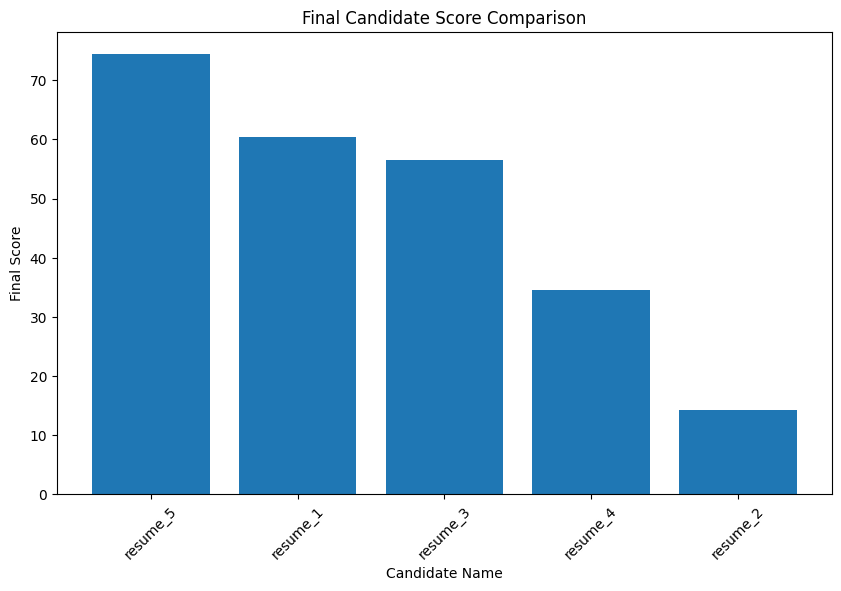

In [109]:
plt.figure()

plt.bar(
    ranking_df["candidate_name"],
    ranking_df["final_score"]
)

plt.title("Final Candidate Score Comparison")
plt.xlabel("Candidate Name")
plt.ylabel("Final Score")
plt.xticks(rotation=45)

plt.show()

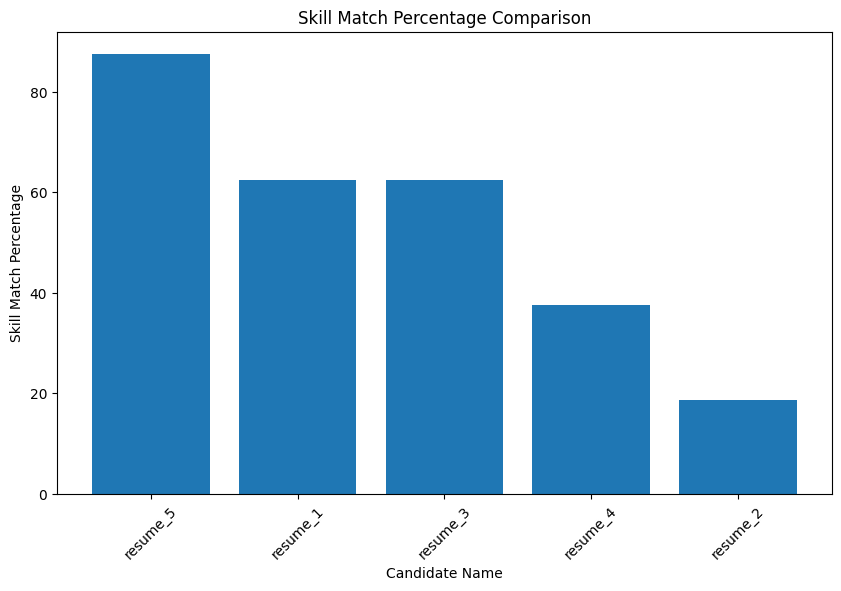

In [110]:
plt.figure()

plt.bar(
    ranking_df["candidate_name"],
    ranking_df["skill_match_percentage"]
)

plt.title("Skill Match Percentage Comparison")
plt.xlabel("Candidate Name")
plt.ylabel("Skill Match Percentage")
plt.xticks(rotation=45)

plt.show()

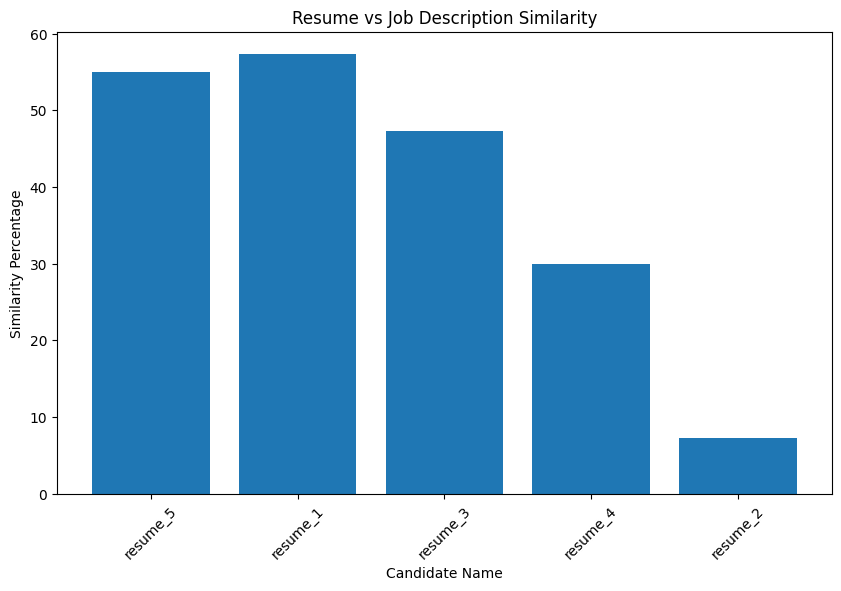

In [111]:
plt.figure()

plt.bar(
    ranking_df["candidate_name"],
    ranking_df["resume_jd_similarity_percentage"]
)

plt.title("Resume vs Job Description Similarity")
plt.xlabel("Candidate Name")
plt.ylabel("Similarity Percentage")
plt.xticks(rotation=45)

plt.show()

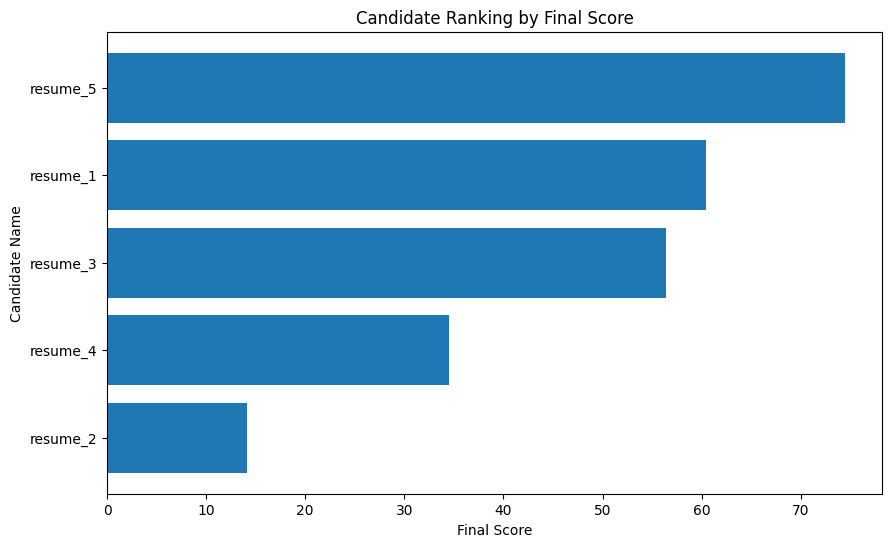

In [112]:
sorted_chart_df = ranking_df.sort_values(by="final_score", ascending=True)

plt.figure()

plt.barh(
    sorted_chart_df["candidate_name"],
    sorted_chart_df["final_score"]
)

plt.title("Candidate Ranking by Final Score")
plt.xlabel("Final Score")
plt.ylabel("Candidate Name")

plt.show()

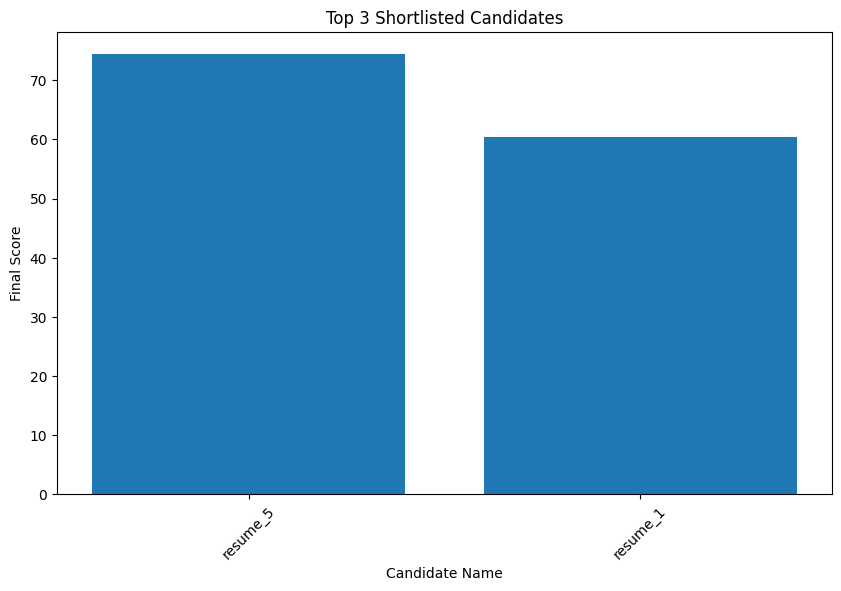

In [113]:
top_3_chart_df = ranking_df.head(3)

plt.figure()

plt.bar(
    top_3_chart_df["candidate_name"],
    top_3_chart_df["final_score"]
)

plt.title("Top 3 Shortlisted Candidates")
plt.xlabel("Candidate Name")
plt.ylabel("Final Score")
plt.xticks(rotation=45)

plt.show()

In [114]:
comparison_df = ranking_df[[
    "candidate_name",
    "skill_match_percentage",
    "resume_jd_similarity_percentage",
    "final_score"
]]

comparison_df

,candidate_name,skill_match_percentage,resume_jd_similarity_percentage,final_score
0,resume_5,87.50,54.95,74.48
1,resume_5,87.50,54.95,74.48
2,resume_1,62.50,57.35,60.44
3,resume_1,62.50,57.35,60.44
4,resume_3,62.50,47.35,56.44
5,resume_3,62.50,47.35,56.44
6,resume_4,37.50,29.95,34.48
7,resume_4,37.50,29.95,34.48
8,resume_2,18.75,7.31,14.17
9,resume_2,18.75,7.31,14.17


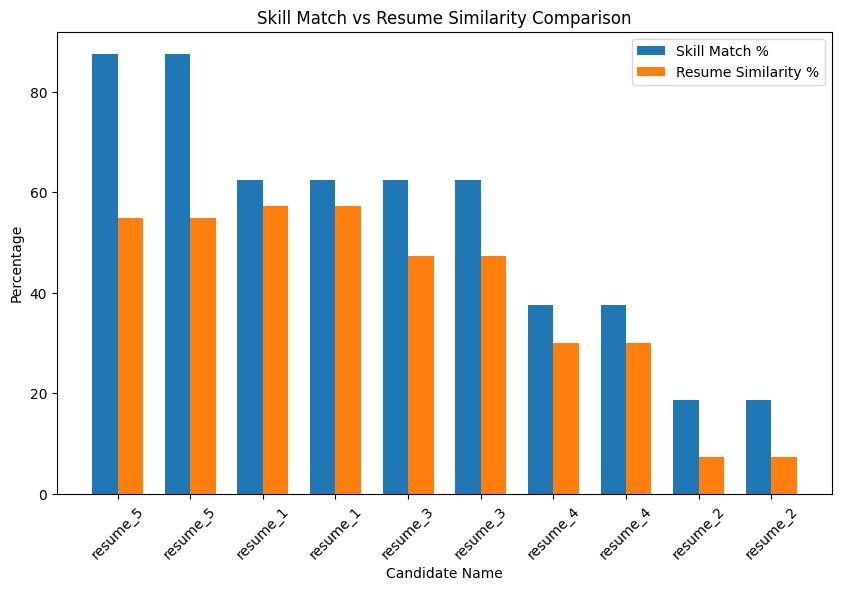

In [115]:
x = np.arange(len(ranking_df))
width = 0.35

plt.figure()

plt.bar(
    x - width/2,
    ranking_df["skill_match_percentage"],
    width,
    label="Skill Match %"
)

plt.bar(
    x + width/2,
    ranking_df["resume_jd_similarity_percentage"],
    width,
    label="Resume Similarity %"
)

plt.xticks(x, ranking_df["candidate_name"], rotation=45)
plt.xlabel("Candidate Name")
plt.ylabel("Percentage")
plt.title("Skill Match vs Resume Similarity Comparison")
plt.legend()

plt.show()

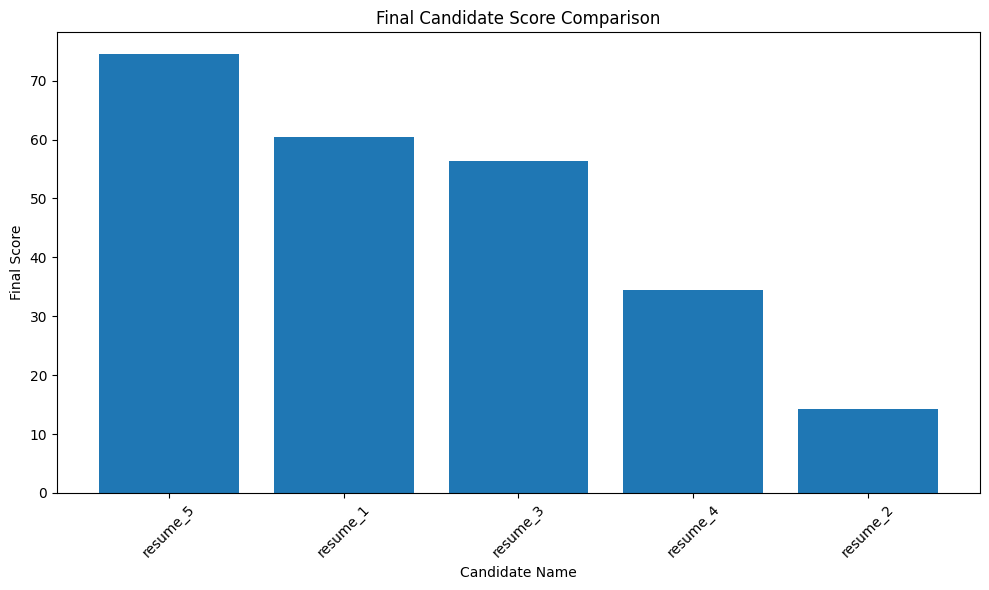

In [116]:
plt.figure()

plt.bar(
    ranking_df["candidate_name"],
    ranking_df["final_score"]
)

plt.title("Final Candidate Score Comparison")
plt.xlabel("Candidate Name")
plt.ylabel("Final Score")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("outputs/final_score_chart.png")
plt.show()

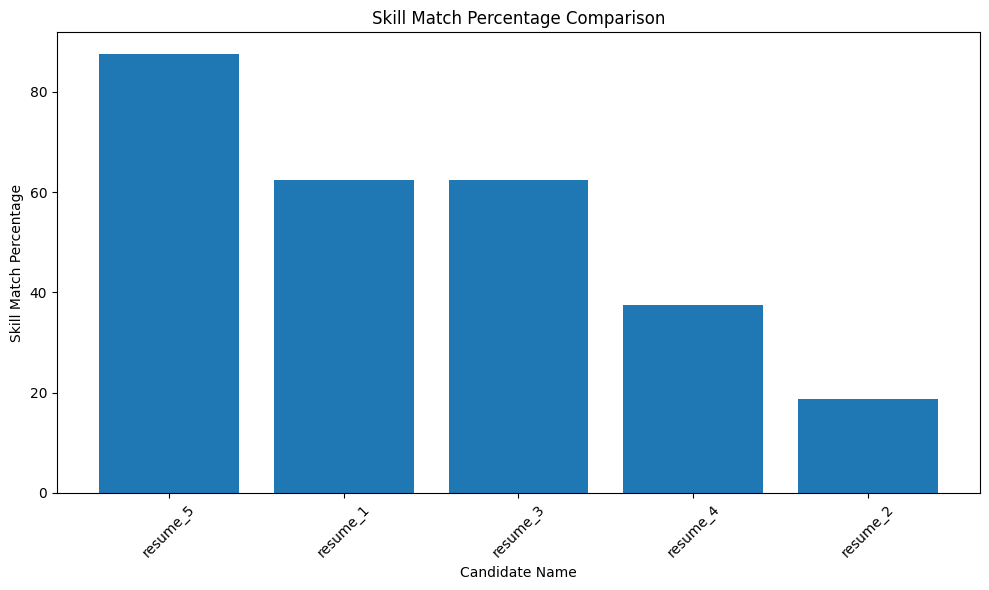

In [117]:
plt.figure()

plt.bar(
    ranking_df["candidate_name"],
    ranking_df["skill_match_percentage"]
)

plt.title("Skill Match Percentage Comparison")
plt.xlabel("Candidate Name")
plt.ylabel("Skill Match Percentage")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("outputs/skill_match_chart.png")
plt.show()

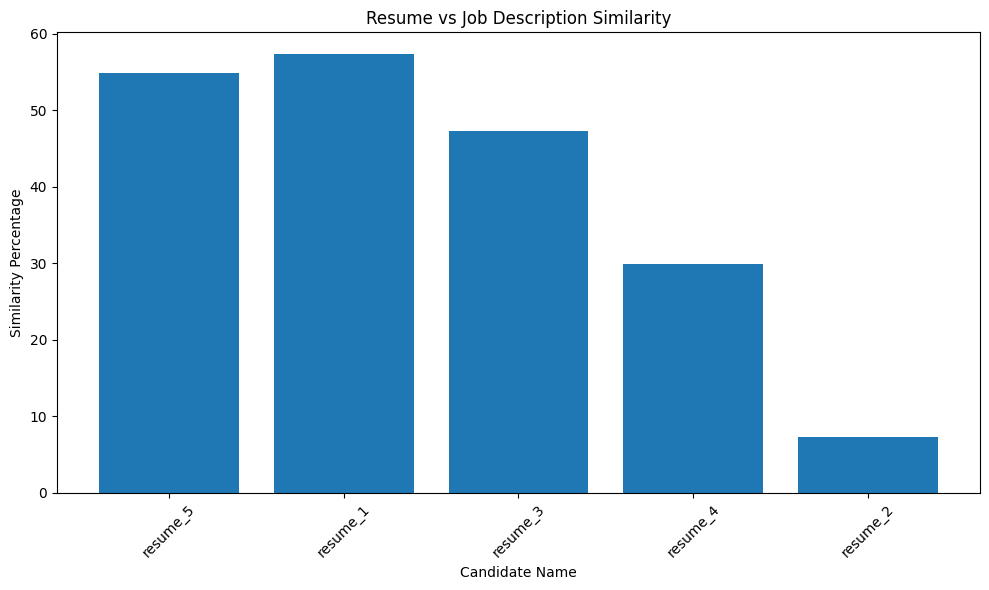

In [118]:
plt.figure()

plt.bar(
    ranking_df["candidate_name"],
    ranking_df["resume_jd_similarity_percentage"]
)

plt.title("Resume vs Job Description Similarity")
plt.xlabel("Candidate Name")
plt.ylabel("Similarity Percentage")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("outputs/similarity_chart.png")
plt.show()

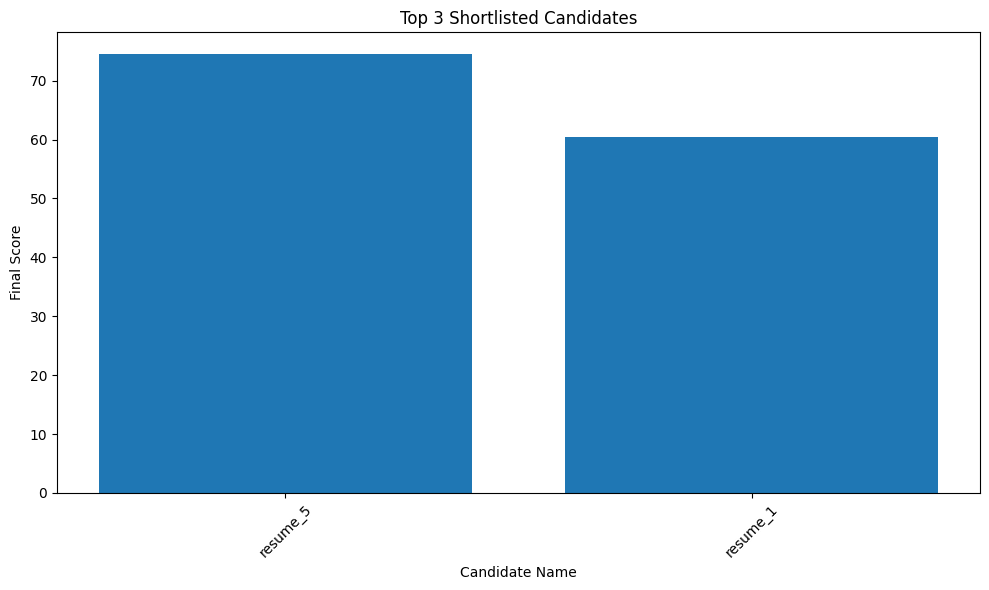

In [119]:
plt.figure()

plt.bar(
    top_3_chart_df["candidate_name"],
    top_3_chart_df["final_score"]
)

plt.title("Top 3 Shortlisted Candidates")
plt.xlabel("Candidate Name")
plt.ylabel("Final Score")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("outputs/top_3_candidates_chart.png")
plt.show()

In [120]:
print(os.listdir("outputs"))

['final_candidate_ranking_with_tags.csv', 'raw_resume_data.csv', 'top_3_candidates.csv', 'final_score_chart.png', 'resume_skill_analysis.csv', 'skill_match_chart.png', 'final_candidate_ranking.csv', 'smarthire_final_report.csv', 'processed_resume_data.csv', 'similarity_chart.png', 'resume_similarity_analysis.csv', 'top_3_candidates_chart.png']


In [121]:
final_report_df

,rank,candidate_name,final_score,recommendation,matched_skill_count,missing_skill_count,matched_skills,missing_skills,candidate_summary,recruiter_note
0,1,resume_5,74.48,Moderately Suitable,14,2,"[data visualization, sql, python, problem solv...","[data analysis, power bi]",resume_5 is a reasonably suitable candidate wi...,Candidate resume_5 received a final SmartHire ...
1,2,resume_5,74.48,Moderately Suitable,14,2,"[data visualization, sql, python, problem solv...","[data analysis, power bi]",resume_5 is a reasonably suitable candidate wi...,Candidate resume_5 received a final SmartHire ...
2,3,resume_1,60.44,Moderately Suitable,10,6,"[sql, python, machine learning, numpy, pandas,...","[data visualization, problem solving, tableau,...",resume_1 is a reasonably suitable candidate wi...,Candidate resume_1 received a final SmartHire ...
3,4,resume_1,60.44,Moderately Suitable,10,6,"[sql, python, machine learning, numpy, pandas,...","[data visualization, problem solving, tableau,...",resume_1 is a reasonably suitable candidate wi...,Candidate resume_1 received a final SmartHire ...
4,5,resume_3,56.44,Moderately Suitable,10,6,"[data visualization, sql, python, machine lear...","[problem solving, scikit-learn, data analysis,...",resume_3 is a reasonably suitable candidate wi...,Candidate resume_3 received a final SmartHire ...
5,6,resume_3,56.44,Moderately Suitable,10,6,"[data visualization, sql, python, machine lear...","[problem solving, scikit-learn, data analysis,...",resume_3 is a reasonably suitable candidate wi...,Candidate resume_3 received a final SmartHire ...
6,7,resume_4,34.48,Low Match,6,10,"[python, problem solving, excel, data analysis...","[data visualization, sql, machine learning, nu...",resume_4 is currently a low match for the role...,Candidate resume_4 received a final SmartHire ...
7,8,resume_4,34.48,Low Match,6,10,"[python, problem solving, excel, data analysis...","[data visualization, sql, machine learning, nu...",resume_4 is currently a low match for the role...,Candidate resume_4 received a final SmartHire ...
8,9,resume_2,14.17,Low Match,3,13,"[sql, problem solving, communication]","[data visualization, python, machine learning,...",resume_2 is currently a low match for the role...,Candidate resume_2 received a final SmartHire ...
9,10,resume_2,14.17,Low Match,3,13,"[sql, problem solving, communication]","[data visualization, python, machine learning,...",resume_2 is currently a low match for the role...,Candidate resume_2 received a final SmartHire ...
